In [ ]:
import sys 
from pathlib import Path 

print("Python:", sys.executable) # print the path to the Python executable being used
print("Working directory:", Path.cwd()) # print the current working directory

Python: c:\Users\megdo\Desktop\underwater-object-detection\venv\Scripts\python.exe
Working directory: c:\Users\megdo\Desktop\underwater-object-detection\notebooks


In [ ]:
import sys 

print(sys.executable) # print the path to the Python executable being used

c:\Users\megdo\Desktop\underwater-object-detection\venv\Scripts\python.exe


In [ ]:
from pathlib import Path # import Path class from the pathlib module to handle file system paths

PROJECT_ROOT = Path.cwd().parent # set the project root directory to the parent of the current working directory

if not (PROJECT_ROOT / "configs").exists(): # check if the  directory exists in the project root, and raise a FileNotFoundError if it does not
    PROJECT_ROOT = Path.cwd() # set the project root directory to the current working directory if the "configs" directory does not exist in the parent directory

DATA_YAML = PROJECT_ROOT / "configs" / "duo.yaml"
WEIGHTS = PROJECT_ROOT / "models" / "pretrained" / "yolov8n.pt"

print("Project root:", PROJECT_ROOT.resolve())
print("Dataset YAML exists:", DATA_YAML.exists())
print("Weights exist:", WEIGHTS.exists())

Project root: C:\Users\megdo\Desktop\underwater-object-detection
Dataset YAML exists: True
Weights exist: True


In [ ]:
import ultralytics # import the ultralytics library, which is used for training and deploying YOLO models

print("Ultralytics version:", ultralytics.__version__) # print the version of the ultralytics library being used

Ultralytics version: 8.4.99


In [ ]:
import torch # import the PyTorch library, which is used for deep learning and tensor computations

print("PyTorch version:", torch.__version__) # print the version of the PyTorch library being used
print("CUDA available:", torch.cuda.is_available()) # print whether CUDA (GPU support) is available

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Training will use the CPU.")

PyTorch version: 2.13.0+cpu
CUDA available: False
Training will use the CPU.


In [ ]:
#checking YOLO pipeline works (not full dataset, just a few images to check the pipeline))
from ultralytics import YOLO

model = YOLO(str(WEIGHTS)) # load the YOLO model using the specified weights file

results = model.train( # train the YOLO model using the specified parameters
    data=str(DATA_YAML),
    epochs=1,
    imgsz=320,
    batch=1,
    device="cpu",
    workers=0,
    seed=42,
    fraction=0.01,
    project=str(PROJECT_ROOT / "results" / "yolov8"),
    name="pipeline_test_1epoch",
    exist_ok=True,
)

Ultralytics 8.4.99  Python-3.13.7 torch-2.13.0+cpu CPU (12th Gen Intel Core i7-1255U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\megdo\Desktop\underwater-object-detection\configs\duo.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.01, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=c:\Users\megdo\Desktop\underwater-object-detection\models\pretrained\yolov8n.pt, momentum=0.937, mosaic=1

In [ ]:
from pathlib import Path # import Path class from the pathlib module to handle file system paths

output_dir = ( # define the output directory for the training results
    PROJECT_ROOT
    / "results"
    / "yolov8"
    / "pipeline_test_1epoch"
)

for path in output_dir.rglob("*"): # recursively search for all files in the output directory and its subdirectories
    if path.is_file():
        print(path.relative_to(output_dir))

args.yaml
BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights\best.pt
weights\last.pt


In [ ]:
#slightly larger trial to check if the pipeline works with a few more images and epochs
from ultralytics import YOLO

model = YOLO(str(WEIGHTS)) # load the YOLO model using the specified weights file

development_results = model.train( # train the YOLO model using the specified parameters
    data=str(DATA_YAML),
    epochs=3,
    imgsz=320,
    batch=1,
    device="cpu",
    workers=0,
    seed=42,
    fraction=0.05,
    project=str(PROJECT_ROOT / "results" / "yolov8"),
    name="development_test_3epochs",
    exist_ok=True,
)

Ultralytics 8.4.99  Python-3.13.7 torch-2.13.0+cpu CPU (12th Gen Intel Core i7-1255U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\megdo\Desktop\underwater-object-detection\configs\duo.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.05, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=c:\Users\megdo\Desktop\underwater-object-detection\models\pretrained\yolov8n.pt, momentum=0.937, mosaic=1

In [ ]:
#inspecting the results of the development test
from pathlib import Path

development_dir = ( # define the output directory for the development test results
    PROJECT_ROOT
    / "results"
    / "yolov8"
    / "development_test_3epochs"
)

for file_path in development_dir.rglob("*"): # recursively search for all files in the development test output directory and its subdirectories
    if file_path.is_file():
        print(file_path.relative_to(development_dir))

#displaying training plots for the development test
from PIL import Image
import matplotlib.pyplot as plt

results_plot = development_dir / "results.png" # define the path to the training results plot image

image = Image.open(results_plot) # open the training results plot image using the PIL library

plt.figure(figsize=(14, 9))
plt.imshow(image)
plt.axis("off")
plt.show()


#display a confusion matrix for the development test
confusion_matrix_path = (
    development_dir
    / "confusion_matrix_normalized.png"
)

if not confusion_matrix_path.exists(): # check if the confusion matrix image file exists, and if not, use the non-normalized version
    confusion_matrix_path = (
        development_dir
        / "confusion_matrix.png"
    )

image = Image.open(confusion_matrix_path) # open the confusion matrix image using the PIL library

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

#viwing validation results for the development test
validation_images = sorted(
    development_dir.glob("val_batch*_pred.jpg")
)

for path in validation_images: # iterate through the validation result images and print their names
    print(path.name)


    prediction_image = Image.open(validation_images[0])

plt.figure(figsize=(14, 9))
plt.imshow(prediction_image)
plt.axis("off")
plt.show()


ground_truth_images = sorted( # get a sorted list of ground truth label images from the development test output directory
    development_dir.glob("val_batch*_labels.jpg")
)

ground_truth_image = Image.open(ground_truth_images[0]) # open the first ground truth label image using the PIL library

plt.figure(figsize=(14, 9))
plt.imshow(ground_truth_image)
plt.axis("off")
plt.show()

args.yaml
BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights\best.pt
weights\last.pt


<Figure size 1400x900 with 1 Axes>

<Figure size 1000x800 with 1 Axes>

val_batch0_pred.jpg
val_batch1_pred.jpg
val_batch2_pred.jpg


<Figure size 1400x900 with 1 Axes>

<Figure size 1400x900 with 1 Axes>

In [ ]:
#inspecting images from first vlidation batch for the development test
from PIL import Image
import matplotlib.pyplot as plt

image_path = development_dir / "val_batch0_pred.jpg" # define the path to the first validation batch prediction image

image = Image.open(image_path) # open the first validation batch prediction image using the PIL library

plt.figure(figsize=(14, 9))
plt.imshow(image)
plt.axis("off")
plt.show()

#comparing with labels
image_path = development_dir / "val_batch0_labels.jpg"

image = Image.open(image_path) # open the first validation batch label image using the PIL library

plt.figure(figsize=(14, 9))
plt.imshow(image)
plt.axis("off")
plt.show()

<Figure size 1400x900 with 1 Axes>

<Figure size 1400x900 with 1 Axes>

Results folder: c:\Users\megdo\Desktop\underwater-object-detection\results\yolov8\development_test_3epochs
Folder exists: True
Prediction image exists: True
Ground-truth image exists: True

Model predictions:


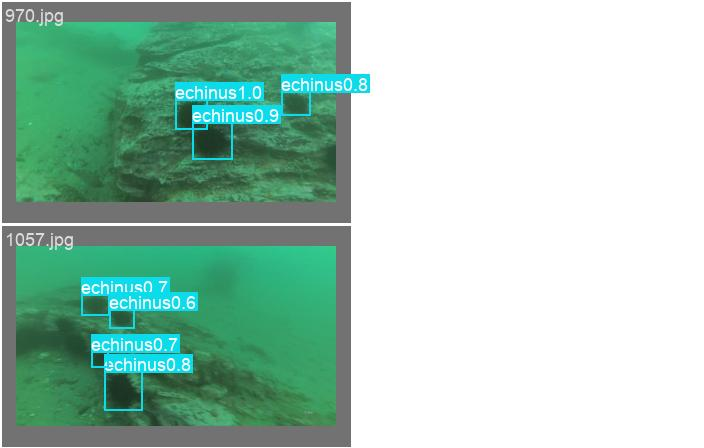


Ground-truth labels:


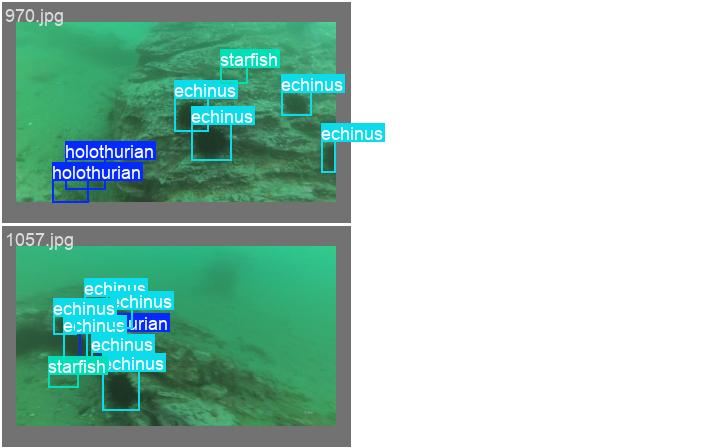

In [ ]:
from pathlib import Path # import Path class from the pathlib module to handle file system paths

import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display # import the display function from the IPython.display module to display images in Jupyter notebooks


# Ensure figures are displayed inside the notebook
%matplotlib inline


# Locate the development-run results folder
development_dir = (
    PROJECT_ROOT
    / "results"
    / "yolov8"
    / "development_test_3epochs"
)

print("Results folder:", development_dir)
print("Folder exists:", development_dir.exists())


# Define the prediction and ground-truth image paths
prediction_path = development_dir / "val_batch0_pred.jpg"
labels_path = development_dir / "val_batch0_labels.jpg"

print("Prediction image exists:", prediction_path.exists())
print("Ground-truth image exists:", labels_path.exists())


# Display the prediction image
if prediction_path.exists():
    prediction_image = Image.open(prediction_path)

    print("\nModel predictions:")
    display(prediction_image)
else:
    print("Prediction image was not found.")


# Display the corresponding ground-truth annotations
if labels_path.exists():
    labels_image = Image.open(labels_path)

    print("\nGround-truth labels:")
    display(labels_image)
else:
    print("Ground-truth image was not found.")

In [ ]:
#full Yolo baseline trial with the full dataset and 1 epoch to get a timing estimate
from ultralytics import YOLO
import time

model = YOLO(str(WEIGHTS)) # load the YOLO model using the specified weights file

start_time = time.time() # record the start time before training begins

timing_results = model.train( # train the YOLO model using the specified parameters
    data=str(DATA_YAML),
    epochs=1,
    imgsz=416,
    batch=2,
    device="cpu",
    workers=0,
    seed=42,
    project=str(PROJECT_ROOT / "results" / "yolov8"),
    name="full_dataset_timing_test",
    exist_ok=True,
)

elapsed_seconds = time.time() - start_time # calculate the elapsed time in seconds by subtracting the start time from the current time
elapsed_hours = elapsed_seconds / 3600 # convert the elapsed time from seconds to hours

print(f"Total elapsed time: {elapsed_hours:.2f} hours")


#time it takes
planned_epochs = 30
estimated_hours = elapsed_hours * planned_epochs

print(
    f"Estimated time for {planned_epochs} epochs: "
    f"{estimated_hours:.1f} hours"
)

Ultralytics 8.4.99  Python-3.13.7 torch-2.13.0+cpu CPU (12th Gen Intel Core i7-1255U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\megdo\Desktop\underwater-object-detection\configs\duo.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=c:\Users\megdo\Desktop\underwater-object-detection\models\pretrained\yolov8n.pt, momentum=0.937, mosaic=1.

In [ ]:
#full rule 30 epochs training with the full dataset
from ultralytics import YOLO

model = YOLO(str(WEIGHTS)) 

baseline_results = model.train( # train the YOLO model using the specified parameters
    data=str(DATA_YAML),
    epochs=30,
    imgsz=416,
    batch=2,
    device="cpu",
    workers=0,
    seed=42,
    patience=7,
    project=str(PROJECT_ROOT / "results" / "yolov8"),
    name="duo_yolov8n_baseline",
    exist_ok=False,
)

Ultralytics 8.4.99  Python-3.13.7 torch-2.13.0+cpu CPU (12th Gen Intel Core i7-1255U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\megdo\Desktop\underwater-object-detection\configs\duo.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=c:\Users\megdo\Desktop\underwater-object-detection\models\pretrained\yolov8n.pt, momentum=0.937, mosaic=

In [ ]:
from pathlib import Path
from ultralytics import YOLO

# Recreate the project paths
PROJECT_ROOT = Path.cwd().parent

if not (PROJECT_ROOT / "configs").exists(): 
    PROJECT_ROOT = Path.cwd()

DATA_YAML = PROJECT_ROOT / "configs" / "duo.yaml" # specify the path to the dataset configuration file

baseline_dir = ( # define the output directory for the baseline training results
    PROJECT_ROOT
    / "results"
    / "yolov8"
    / "duo_yolov8n_baseline"
)

best_weights = baseline_dir / "weights" / "best.pt"

print("Project root:", PROJECT_ROOT.resolve())
print("Dataset YAML found:", DATA_YAML.exists())
print("Best weights found:", best_weights.exists())

Project root: C:\Users\megdo\Desktop\underwater-object-detection
Dataset YAML found: True
Best weights found: True


In [3]:
best_model = YOLO(str(best_weights))

test_results = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=416,
    batch=2,
    device="cpu",
    workers=0,
    project=str(PROJECT_ROOT / "results" / "yolov8"),
    name="duo_yolov8n_test_evaluation",
)

Ultralytics 8.4.99  Python-3.13.7 torch-2.13.0+cpu CPU (12th Gen Intel Core i7-1255U)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
WARNING val: Slow image access detected (ping: 0.70.2 ms, read: 21.722.9 MB/s, size: 445.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning C:\Users\megdo\Desktop\underwater-object-detection\data\processed\DUO_yolo\labels\test... 1111 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1111/1111 223.4it/s 5.0s0.1s
val: New cache created: C:\Users\megdo\Desktop\underwater-object-detection\data\processed\DUO_yolo\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 556/556 6.2it/s 1:300.2ssss
                   all       1111      10517      0.727      0.577      0.654      0.446
           holothurian        490       1079      0.721      0.503  

In [4]:
print(f"Test mAP@0.5: {test_results.box.map50:.4f}")
print(f"Test mAP@0.5:0.95: {test_results.box.map:.4f}")
print(f"Test mean precision: {test_results.box.mp:.4f}")
print(f"Test mean recall: {test_results.box.mr:.4f}")

Test mAP@0.5: 0.6542
Test mAP@0.5:0.95: 0.4456
Test mean precision: 0.7273
Test mean recall: 0.5771


In [ ]:
class_names = best_model.names # get the class names from the best model

for class_id, class_name in class_names.items(): # iterate through the class IDs and names, and print the average precision (AP) for each class at IoU thresholds of 0.5 and 0.5:0.95
    print(
        class_name,
        "| AP@0.5:",
        round(test_results.box.ap50[class_id], 4),
        "| AP@0.5:0.95:",
        round(test_results.box.ap[class_id], 4),
    )


    precision = test_results.box.mp # get the mean precision from the test results
recall = test_results.box.mr # get the mean recall from the test results

f1 = (
    2 * precision * recall / (precision + recall)
    if precision + recall > 0
    else 0
)

print(f"Test F1 score: {f1:.4f}")

holothurian | AP@0.5: 0.6118 | AP@0.5:0.95: 0.3879
echinus | AP@0.5: 0.8369 | AP@0.5:0.95: 0.6158
scallop | AP@0.5: 0.3438 | AP@0.5:0.95: 0.2137
starfish | AP@0.5: 0.8242 | AP@0.5:0.95: 0.5649
Test F1 score: 0.6436


In [ ]:
import pandas as pd # import the pandas library, which is used for data manipulation and analysis

overall_results = pd.DataFrame([{ # create a DataFrame to store the overall test results
    "model": "YOLOv8n",
    "dataset": "DUO",
    "image_size": 416,
    "epochs_planned": 30,
    "mAP_0.5": 0.6542,
    "mAP_0.5_0.95": 0.4456,
    "precision": 0.7273,
    "recall": 0.5771,
    "f1_score": 0.6436,
    "inference_ms_per_image": 18.3,
    "approx_fps": 1000 / 18.3,
    "device": "CPU",
}])

output_path = ( # define the output path for the overall test results CSV file
    PROJECT_ROOT
    / "results"
    / "yolov8"
    / "duo_yolov8n_baseline"
    / "test_metrics.csv"
)

overall_results.to_csv(output_path, index=False) # save the overall test results DataFrame to a CSV file at the specified output path

overall_results


class_results = pd.DataFrame({ # create a DataFrame to store the per-class test results
    "class": [
        "holothurian",
        "echinus",
        "scallop",
        "starfish",
    ],
    "AP_0.5": [
        0.6118,
        0.8369,
        0.3438,
        0.8242,
    ],
    "AP_0.5_0.95": [
        0.3879,
        0.6158,
        0.2137,
        0.5649,
    ],
})

class_output_path = ( # define the output path for the per-class test results CSV file
    PROJECT_ROOT
    / "results"
    / "yolov8"
    / "duo_yolov8n_baseline"
    / "class_metrics.csv"
)

class_results.to_csv(class_output_path, index=False) # save the per-class test results DataFrame to a CSV file at the specified output path

class_results

,class,AP_0.5,AP_0.5_0.95
0,holothurian,0.6118,0.3879
1,echinus,0.8369,0.6158
2,scallop,0.3438,0.2137
3,starfish,0.8242,0.5649


In [ ]:
from pathlib import Path
import platform

import pandas as pd
import torch
import ultralytics


# Locate the completed baseline run
baseline_dir = (
    PROJECT_ROOT
    / "results"
    / "yolov8"
    / "duo_yolov8n_baseline"
)

results_csv = baseline_dir / "results.csv" # define the path to the results CSV file containing epoch-by-epoch training results
args_yaml = baseline_dir / "args.yaml" # define the path to the arguments YAML file containing training configuration parameters

print("Baseline folder found:", baseline_dir.exists())
print("Results CSV found:", results_csv.exists())
print("Arguments file found:", args_yaml.exists())


# Load the epoch-by-epoch training results
results_df = pd.read_csv(results_csv)

# Remove any spaces that Ultralytics may include in column names
results_df.columns = results_df.columns.str.strip()

print("\nAvailable result columns:")
print(results_df.columns.tolist())


# Actual number of epochs completed
actual_epochs = len(results_df)

print("\nActual epochs completed:", actual_epochs)


# Determine the best epoch

# Ultralytics usually chooses best.pt using a combined fitness score, if a fitness column is available, use it
if "fitness" in results_df.columns:
    best_row_index = results_df["fitness"].idxmax()
    selection_metric = "fitness"

# Otherwise use validation mAP@0.5:0.95 as the clearest proxy for overall model performanc
elif "metrics/mAP50-95(B)" in results_df.columns:
    best_row_index = results_df["metrics/mAP50-95(B)"].idxmax()
    selection_metric = "validation mAP@0.5:0.95"

else: # if neither fitness nor validation mAP@0.5:0.95 columns are available, set best_row_index and selection_metric to None
    best_row_index = None
    selection_metric = None


if best_row_index is not None:
    # Ultralytics epoch numbering normally starts from zero in results.csv
    if "epoch" in results_df.columns:
        recorded_epoch = int(results_df.loc[best_row_index, "epoch"])
        best_epoch = recorded_epoch + 1
    else:
        best_epoch = int(best_row_index) + 1

    print("Best epoch:", best_epoch)
    print("Best epoch selected using:", selection_metric)

    if "metrics/mAP50-95(B)" in results_df.columns:
        print(
            "Best validation mAP@0.5:0.95:",
            round(
                results_df.loc[
                    best_row_index,
                    "metrics/mAP50-95(B)"
                ],
                4,
            ),
        )
else:
    print(
        "Best epoch could not be identified automatically. "
        "Inspect the results.csv columns printed above."
    )



# Total training time:
if "time" in results_df.columns:
    # Ultralytics normally records cumulative elapsed seconds
    total_seconds = float(results_df["time"].iloc[-1])
    total_hours = total_seconds / 3600

    print(
        "Total recorded training time:",
        f"{total_hours:.2f} hours",
    )

    print(
        "Total recorded training time:",
        f"{total_seconds / 60:.1f} minutes",
    )
else:
    print(
        "No time column was found in results.csv. "
        "Use the elapsed time shown in the training output."
    )


# Software and hardware information
print("\nUltralytics version:", ultralytics.__version__)
print("PyTorch version:", torch.__version__)
print("Python version:", platform.python_version())
print("Operating system:", platform.platform())

processor = platform.processor() # get the processor name using the platform module

if not processor: # if the processor name is not available, use the uname() function to get the processor information
    processor = platform.uname().processor

print("Processor:", processor)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available(): # print the name of the GPU device being used for training
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Training device: CPU") 



    print(args_yaml.read_text(encoding="utf-8")) # print the contents of the arguments YAML file used for training, which contains the configuration parameters

Baseline folder found: True
Results CSV found: True
Arguments file found: True

Available result columns:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

Actual epochs completed: 24
Best epoch: 18
Best epoch selected using: validation mAP@0.5:0.95
Best validation mAP@0.5:0.95: 0.4615
Total recorded training time: 5.76 hours
Total recorded training time: 345.4 minutes

Ultralytics version: 8.4.99
PyTorch version: 2.13.0+cpu
Python version: 3.13.7
Operating system: Windows-11-10.0.26200-SP0
Processor: Intel64 Family 6 Model 154 Stepping 4, GenuineIntel
CUDA available: False
Training device: CPU
task: detect
mode: train
model: c:\Users\megdo\Desktop\underwater-object-detection\models\pretrained\yolov8n.pt
data: c:\Users\megdo\Desktop\underwater-object-detection\configs\duo.yaml
epochs: 30
time: null
p